<a href="https://colab.research.google.com/github/Inventor-creator/Learning-Machine-Learning-and-Deep-Learning/blob/main/learning_basic_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch import relu

In [130]:
# Define a simple model
class SimpleModel(nn.Module):
  def __init__(self):
    super(SimpleModel, self).__init__()
    self.relu = nn.Linear(10, 5) # Input size 10, output size 5
  def forward(self, x):
    return self.relu(x)


# Check CUDA availability
if torch.cuda.is_available():
  device = torch.device('cuda')
  print("CUDA is available! Training on GPU...")
else:
  device = torch.device('cpu')
  print("CUDA is NOT available. Training on CPU...")
# Instantiate the model
model = SimpleModel()
# Move the model to the GPU
model.to(device)
# Create some sample input data
input_data = torch.randn(1, 10)  # Batch size 1, input size 10
# Move the input data to the GPU
input_data = input_data.to(device)
# Perform a forward pass
output = model(input_data)
print("Output:", output)
print("Output Device:", output.device)

CUDA is NOT available. Training on CPU...
Output: tensor([[ 0.1784, -1.3830,  0.4440, -0.2024,  0.3999]],
       grad_fn=<AddmmBackward0>)
Output Device: cpu


In [131]:
tensor = torch.randint( size=(5,10,2), low=10 , high=20 )

In [132]:
tensor

tensor([[[15, 15],
         [18, 13],
         [16, 11],
         [18, 14],
         [17, 11],
         [15, 18],
         [16, 10],
         [14, 18],
         [13, 10],
         [13, 19]],

        [[14, 14],
         [17, 16],
         [17, 17],
         [10, 19],
         [17, 15],
         [11, 14],
         [15, 14],
         [11, 18],
         [14, 18],
         [19, 18]],

        [[18, 13],
         [18, 18],
         [10, 19],
         [18, 19],
         [16, 12],
         [13, 17],
         [18, 11],
         [14, 11],
         [16, 11],
         [18, 16]],

        [[15, 10],
         [14, 16],
         [12, 12],
         [18, 18],
         [18, 18],
         [19, 12],
         [13, 10],
         [12, 10],
         [19, 12],
         [12, 15]],

        [[13, 10],
         [15, 13],
         [11, 16],
         [17, 14],
         [10, 13],
         [18, 18],
         [13, 13],
         [11, 14],
         [17, 11],
         [13, 16]]])

In [133]:
tensor2 = torch.arange(50)

In [134]:
tensor2

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [135]:
tensor2.reshape(5,10,-1)

tensor([[[ 0],
         [ 1],
         [ 2],
         [ 3],
         [ 4],
         [ 5],
         [ 6],
         [ 7],
         [ 8],
         [ 9]],

        [[10],
         [11],
         [12],
         [13],
         [14],
         [15],
         [16],
         [17],
         [18],
         [19]],

        [[20],
         [21],
         [22],
         [23],
         [24],
         [25],
         [26],
         [27],
         [28],
         [29]],

        [[30],
         [31],
         [32],
         [33],
         [34],
         [35],
         [36],
         [37],
         [38],
         [39]],

        [[40],
         [41],
         [42],
         [43],
         [44],
         [45],
         [46],
         [47],
         [48],
         [49]]])

In [136]:
tensor + tensor2.reshape(5,10,-1)

tensor([[[15, 15],
         [19, 14],
         [18, 13],
         [21, 17],
         [21, 15],
         [20, 23],
         [22, 16],
         [21, 25],
         [21, 18],
         [22, 28]],

        [[24, 24],
         [28, 27],
         [29, 29],
         [23, 32],
         [31, 29],
         [26, 29],
         [31, 30],
         [28, 35],
         [32, 36],
         [38, 37]],

        [[38, 33],
         [39, 39],
         [32, 41],
         [41, 42],
         [40, 36],
         [38, 42],
         [44, 37],
         [41, 38],
         [44, 39],
         [47, 45]],

        [[45, 40],
         [45, 47],
         [44, 44],
         [51, 51],
         [52, 52],
         [54, 47],
         [49, 46],
         [49, 47],
         [57, 50],
         [51, 54]],

        [[53, 50],
         [56, 54],
         [53, 58],
         [60, 57],
         [54, 57],
         [63, 63],
         [59, 59],
         [58, 61],
         [65, 59],
         [62, 65]]])

In [137]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')



In [138]:
print(df.columns)
types = []
for i in df.columns:
  types.append(type(i))

print(types)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


In [139]:
yTarget = df['Survived']

In [140]:
yTarget = yTarget.to_numpy().reshape(-1, 1)


In [141]:
temp = np.array([])
for i in yTarget:
    if i == 0:
        temp = np.append(temp , 1)
    else:
        temp = np.append(temp , 0)



In [142]:
yTarget = np.append(temp.reshape(-1,1) , yTarget , axis=1)

#yTarget = torch.tensor(yTarget , dtype=torch.float32)


In [143]:

yTarget = torch.tensor(yTarget )


In [144]:
df.drop(columns=['Name','Fare','Survived','Ticket'], inplace=True)

In [145]:
?Pipeline

In [146]:
def cabinSort(cabinNum ):

  if cabinNum is np.nan:
    return '0'
  else:
    return cabinNum[0]



df['Cabin'] = df['Cabin'].apply(cabinSort)
df['Embarked'] = df['Embarked'].fillna('nan')

In [147]:
df.isna().any()

PassengerId    False
Pclass         False
Sex            False
Age             True
SibSp          False
Parch          False
Cabin          False
Embarked       False
dtype: bool

In [148]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [149]:
df['Age'].fillna(-1, inplace=True)


/var/folders/5m/_j_596211w579lz0xp790_0m0000gn/T/ipykernel_47900/1435753638.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(-1, inplace=True)


In [150]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
cols = df.columns



transformer = ColumnTransformer([
    ('labelEncoder', OrdinalEncoder() , ['Sex', 'Cabin', "Embarked"]),


], remainder='passthrough')

normalizerPipe = Pipeline(steps=[
    ("transformer" , transformer),
    ("scaler",StandardScaler())
])

df = normalizerPipe.fit_transform(df)

In [151]:
df

array([[ 0.73769513, -0.48846066,  0.58111394, ..., -0.0896342 ,
         0.43279337, -0.47367361],
       [-1.35557354,  1.39832453, -1.93846038, ...,  0.80634954,
         0.43279337, -0.47367361],
       [-1.35557354, -0.48846066,  0.58111394, ...,  0.13436174,
        -0.4745452 , -0.47367361],
       ...,
       [-1.35557354, -0.48846066,  0.58111394, ..., -1.37761082,
         0.43279337,  2.00893337],
       [ 0.73769513,  1.39832453, -1.93846038, ...,  0.13436174,
        -0.4745452 , -0.47367361],
       [ 0.73769513, -0.48846066, -0.67867322, ...,  0.47035564,
        -0.4745452 , -0.47367361]], shape=(891, 8))

In [152]:
df[0]

array([ 0.73769513, -0.48846066,  0.58111394, -1.73010796,  0.82737724,
       -0.0896342 ,  0.43279337, -0.47367361])

In [153]:
cleanedDataTensor = torch.tensor(df)
len(cleanedDataTensor)


891

In [154]:

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [155]:
cleanedDataTensor[0].shape


torch.Size([8])

In [156]:
yTarget

tensor([[1., 0.],
        [0., 1.],
        [0., 1.],
        ...,
        [1., 0.],
        [0., 1.],
        [1., 0.]], dtype=torch.float64)

In [178]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler

model = Network()
loss = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005 )
scheduler = lr_scheduler.StepLR(optimizer, step_size=18, gamma=0.5)

dataset = TensorDataset(cleanedDataTensor, yTarget)
dataloader = DataLoader(dataset, batch_size=32 ,shuffle=True)


In [179]:
epochs = 50

epochNum = []
lossatNum = []

for i in range(epochs):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad()
        outputs = model.forward(inputs.to(torch.float32))
        # print(outputs)
        loss_value = loss(outputs, targets)
        loss_value.backward()
        optimizer.step()
        scheduler.step()

    epochNum.append(i+1)
    lossatNum.append(loss_value.item())
    print(f"Epoch {i+1}/{epochs}, Loss: {loss_value.item()}")


Epoch 1/50, Loss: 0.6654351755148835
Epoch 2/50, Loss: 0.6556228407555156
Epoch 3/50, Loss: 0.6572372594641315
Epoch 4/50, Loss: 0.6587703697107457
Epoch 5/50, Loss: 0.6588788549933169
Epoch 6/50, Loss: 0.6827321626521923
Epoch 7/50, Loss: 0.6857161466722135
Epoch 8/50, Loss: 0.6651060410119869
Epoch 9/50, Loss: 0.6636159442089222
Epoch 10/50, Loss: 0.6337993416797232
Epoch 11/50, Loss: 0.6871498714166658
Epoch 12/50, Loss: 0.6734586211818235
Epoch 13/50, Loss: 0.7077307512086851
Epoch 14/50, Loss: 0.642983730054564
Epoch 15/50, Loss: 0.6873717578472914
Epoch 16/50, Loss: 0.6645946926264851
Epoch 17/50, Loss: 0.6688629983475914
Epoch 18/50, Loss: 0.6669001059123764
Epoch 19/50, Loss: 0.6921654186315007
Epoch 20/50, Loss: 0.6729127466678619
Epoch 21/50, Loss: 0.6648587689355567
Epoch 22/50, Loss: 0.6501899393344367
Epoch 23/50, Loss: 0.6526577420256756
Epoch 24/50, Loss: 0.6756306439638138
Epoch 25/50, Loss: 0.6972351408115139
Epoch 26/50, Loss: 0.6814236304274311
Epoch 27/50, Loss: 0.6

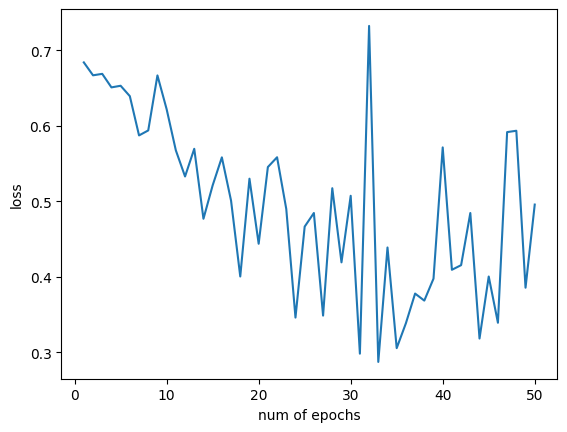

In [177]:
import matplotlib.pyplot as plt

plt.plot(epochNum , lossatNum)
plt.xlabel("num of epochs")
plt.ylabel("loss")
plt.show()